## 11-06-2026 INTRODUCTION TO STATISTICS
Statistics is all about collecting, organizing, analyzing, and interpreting data so we can make smart decisions even when things are uncertain. Raw numbers don't tell the full story — statistics helps turn them into meaningful insights.

Why it matters in real life: Companies use it to predict sales, doctors use it to understand treatment effectiveness, and governments use it for policy making. Without statistics, we'd be guessing instead of knowing.

Topics we'll cover:
1. Types of statistics (descriptive vs inferential)
2. Basic terms (population, sample, etc.)
3. Descriptive statistics with a real student marks example
4. Types of data (categorical vs numerical)
5. Levels of measurement
6. Measures of central tendency (mode, median, mean)
7. Measures of dispersion (range, variance, std dev)
8. Symmetric vs skewed distributions
9. Probability concepts and key distributions
10. The Normal distribution and Empirical Rule

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
np.random.seed(42)  # for reproducibility

### Types of Statistics
There are two main branches:

- **Descriptive Statistics**: This summarizes the data we already have. Think averages, charts, and patterns from the numbers in front of us.
- **Inferential Statistics**: This uses a sample to make educated guesses about a bigger population. Like polling 1000 people to predict election results for millions.

Real example: Measuring the exam scores of 30 students in my class is descriptive. Using those 30 to estimate how the entire school of 2000 students performed is inferential.

In [2]:
# Descriptive: summarize what we have
student_marks = np.array([65, 72, 78, 81, 69, 85, 74, 77, 80, 71, 88, 66, 79, 83, 76,
                         68, 82, 75, 70, 84, 73, 78, 67, 86, 72, 80, 69, 77, 81, 74])
print("Descriptive -> Average marks of these 30 students:", round(student_marks.mean(), 1))

# Inferential: estimate the population
se = student_marks.std(ddof=1) / np.sqrt(len(student_marks))
print("Inferential -> School average likely between", 
      round(student_marks.mean() - 1.96*se, 1), "and", 
      round(student_marks.mean() + 1.96*se, 1), "(95% confidence)")

Descriptive -> Average marks of these 30 students: 76.0
Inferential -> School average likely between 73.7 and 78.3 (95% confidence)


### Basic Terms I Need to Remember
- **Population**: The entire group we're interested in (all students in the country).
- **Sample**: The part we actually measure (students from my college).
- **Variable**: Something that changes, like height or test score.
- **Parameter**: A number describing the whole population (e.g., true average height).
- **Statistic**: A number from the sample (e.g., average height of sampled students).

Parameters are usually unknown, so we use statistics to estimate them.

In [3]:
# Population vs Sample example
population = np.arange(1000, 11000)  # imaginary student IDs as proxy for some metric
sample = np.random.choice(population, size=200, replace=False)
print("Population size (all students):", len(population))
print("Sample size (surveyed):", len(sample))
print("Sample mean (statistic):", round(sample.mean(), 2))

Population size (all students): 10000
Sample size (surveyed): 200
Sample mean (statistic): 5828.95


### Types of Data
Data comes in two big categories:

**1. Categorical (Qualitative)**: Labels or groups. You count frequencies but can't really average them.
   - Examples: Gender, favorite subject, city.

**2. Numerical (Quantitative)**: Actual numbers you can do math with.
   - Discrete: Countable (number of siblings).
   - Continuous: Measured (height, time).

In [4]:
# Categorical example
gender = pd.Series(['M', 'F', 'F', 'M', 'F', 'F', 'M', 'F', 'M', 'F', 'F', 'M', 'F', 'F', 'M', 'F', 'M', 'F', 'F', 'M'])
print("Gender distribution:\n", gender.value_counts())
print("Most common gender:", gender.mode()[0])

Gender distribution:
 F    12
M     8
Name: count, dtype: int64
Most common gender: F


In [5]:
# Numerical example
ages = pd.Series([20, 21, 22, 19, 23, 20, 21, 22, 24, 21, 20, 19, 22, 23, 21, 20, 22, 21, 19, 23])
print("Average age:", round(ages.mean(), 1))
print("Total students surveyed:", ages.count())

Average age: 21.2
Total students surveyed: 20


### Levels of Measurement
This tells us how much information a variable gives:

- **Nominal**: Just categories, no order (blood type, gender).
- **Ordinal**: Categories with order but unequal gaps (grades: A>B>C, satisfaction levels).
- **Interval**: Equal gaps but no true zero (temperature in Celsius, IQ scores).
- **Ratio**: Equal gaps + true zero (height, weight, salary — you can say "twice as much").

### Measures of Central Tendency
These tell us where the "middle" of the data is.

- **Mode**: Most frequent value (great for categories).
- **Median**: Middle value when sorted (resistant to outliers).
- **Mean**: Average (sensitive to extreme values).

In [6]:
# Using our student marks example
print("Mode   :", stats.mode(student_marks, keepdims=False).mode)
print("Median :", np.median(student_marks))
print("Mean   :", round(student_marks.mean(), 1))

Mode   : 69
Median : 76.5
Mean   : 76.0


In [7]:
# Outlier example showing why median is robust
marks_with_outlier = np.append(student_marks, [35])
print("Mean with one low outlier :", round(marks_with_outlier.mean(), 1))
print("Median with one low outlier:", round(np.median(marks_with_outlier), 1))

Mean with one low outlier : 74.7
Median with one low outlier: 76.0


### Measures of Dispersion (Spread)
How spread out the data is:

- **Range**: Max - Min (simple but ignores most data).
- **Variance**: Average squared distance from mean.
- **Standard Deviation**: Square root of variance — in same units as data, very useful.

In [8]:
print("Range          :", student_marks.max() - student_marks.min())
print("Variance       :", round(student_marks.var(ddof=1), 2))
print("Standard Dev   :", round(student_marks.std(ddof=1), 2))

Range          : 23
Variance       : 39.66
Standard Dev   : 6.3


### Distributions and the Normal Curve
Data often follows patterns. The Normal (Bell) distribution is super common — heights, test scores, etc.

**Empirical Rule (68-95-99.7 Rule)**:
- ~68% of data within 1 standard deviation of mean
- ~95% within 2 SD
- ~99.7% within 3 SD

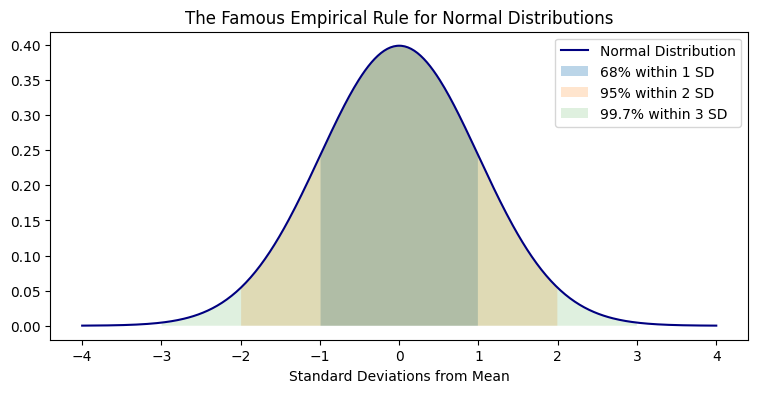

In [9]:
# Visualizing the Empirical Rule
x = np.linspace(-4, 4, 400)
plt.figure(figsize=(9, 4))
plt.plot(x, stats.norm.pdf(x), color='navy', label='Normal Distribution')
for ksd, alpha, label in [(1, 0.3, '68% within 1 SD'), (2, 0.2, '95% within 2 SD'), (3, 0.15, '99.7% within 3 SD')]:
    m = (x >= -ksd) & (x <= ksd)
    plt.fill_between(x[m], stats.norm.pdf(x[m]), alpha=alpha, label=label)
plt.title("The Famous Empirical Rule for Normal Distributions")
plt.xlabel("Standard Deviations from Mean")
plt.legend()
plt.show()

### Recap
- Statistics = descriptive (what we see) + inferential (what we predict)
- Know your data type and measurement level before analyzing
- Centre: mode/median/mean. Spread: range/variance/std
- Outliers affect mean more than median
- Normal distribution + Empirical Rule is a powerful starting point

Next time we'll dive deeper into probability and more distributions!